<a href="https://colab.research.google.com/github/omkar-gupta-hub/RFM-Analysis/blob/main/RFM_Analysis_Using_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 14})

In [6]:

# =====================================================================
# TASK 1: DATA COLLECTION, AUDIT, AND CLEANING (CONSOLIDATED)
# =====================================================================
print("Executing Task 1: Loading, Auditing, and Cleaning base dataset...")

# 1. Load the raw dataset
try:
    df_raw = pd.read_csv('rfm_data.csv')
except FileNotFoundError:
    df_raw = pd.read_csv('/content/rfm_data.csv')

initial_shape = df_raw.shape
print(f"📊 Initial Scan: Loaded {initial_shape[0]} records.")

# 2. Consolidated Integrity Checks (Missing Values & Duplicates Together)
missing_counts = df_raw.isnull().sum()
duplicate_count = df_raw.duplicated().sum()

print("\n🔍 --- DATA INTEGRITY AUDIT ---")
print(f"• Total Duplicate Rows Identified: {duplicate_count}")
print("• Missing Values Detected Per Column:")
print(missing_counts)
print("--------------------------------")

# 3. Clean Missing Values and Duplicates
df_clean = df_raw.dropna().copy()        # Step 2 Guideline: dropna() operational safeguard
df_clean.drop_duplicates(inplace=True)   # Purge duplicate entries

# 4. Step 3 Guideline: Explicit Data Type Conversion Audit
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int).astype(str)
df_clean['PurchaseDate'] = pd.to_datetime(df_clean['PurchaseDate'], format='%d-%m-%Y')
df_clean['TransactionAmount'] = df_clean['TransactionAmount'].astype(float)

# Assign pristine dataset downstream
df = df_clean.copy()

print(f"\n✅ Task 1 Complete. Cleaned Dataset shape: {df.shape}")
print(f"⚠️ Total rows removed (nulls + duplicates): {initial_shape[0] - df.shape[0]}")
print(df.head(2))
print("-" * 80)

Executing Task 1: Loading, Auditing, and Cleaning base dataset...
📊 Initial Scan: Loaded 1000 records.

🔍 --- DATA INTEGRITY AUDIT ---
• Total Duplicate Rows Identified: 0
• Missing Values Detected Per Column:
CustomerID            0
PurchaseDate          0
TransactionAmount     0
ProductInformation    0
OrderID               0
Location              0
dtype: int64
--------------------------------

✅ Task 1 Complete. Cleaned Dataset shape: (1000, 6)
⚠️ Total rows removed (nulls + duplicates): 0
  CustomerID PurchaseDate  TransactionAmount ProductInformation  OrderID  \
0       8814   2023-04-11             943.31          Product C   890075   
1       2188   2023-04-11             463.70          Product A   176819   

  Location  
0    Tokyo  
1   London  
--------------------------------------------------------------------------------


In [7]:
# =====================================================================
# TASK 2: CALCULATION OF RECENCY, FREQUENCY, AND MONETARY (RFM) VALUES[cite: 1]
# =====================================================================
print("Executing Task 2: Calculating core RFM dimensions...")

# 1. Recency: Focus on days elapsed since the global dataset snapshot date[cite: 1]
df_recency = df.groupby(by='CustomerID', as_index=False)['PurchaseDate'].max()
df_recency.columns = ['CustomerID', 'LastPurchaseDate']
recent_date = df_recency['LastPurchaseDate'].max()
df_recency['Recency'] = df_recency['LastPurchaseDate'].apply(lambda x: (recent_date - x).days)

# 2. Frequency: Isolate true purchase dates following initial deduplication steps[cite: 1]
frequency_df = df.drop_duplicates().groupby(by=['CustomerID'], as_index=False)['PurchaseDate'].count()
frequency_df.columns = ['CustomerID', 'Frequency']

# 3. Monetary: Sum total lifetime gross transaction volumes per profile[cite: 1]
df['Total'] = df['TransactionAmount']
monetary_df = df.groupby(by='CustomerID', as_index=False)['Total'].sum()
monetary_df.columns = ['CustomerID', 'Monetary']

# Consolidate metrics into a master RFM index
rfm_df = df_recency.merge(frequency_df, on='CustomerID').merge(monetary_df, on='CustomerID')

print("✅ Task 2 Complete. Metrics calculated successfully.")
print(rfm_df[['CustomerID', 'Recency', 'Frequency', 'Monetary']].head(2))
print("-" * 80)

Executing Task 2: Calculating core RFM dimensions...
✅ Task 2 Complete. Metrics calculated successfully.
  CustomerID  Recency  Frequency  Monetary
0       1011       33          2   1129.02
1       1025       21          1    359.29
--------------------------------------------------------------------------------


In [8]:
# =====================================================================
# TASK 3: ASSIGN SCORES TO THE RFM VALUES[cite: 1]
# =====================================================================
print("Executing Task 3: Normalizing features and engineering weighted RFM score...")

# Establish relative ranks across metric columns[cite: 1]
rfm_df['R_rank'] = rfm_df['Recency'].rank(ascending=False)
rfm_df['F_rank'] = rfm_df['Frequency'].rank(ascending=True)
rfm_df['M_rank'] = rfm_df['Monetary'].rank(ascending=True)

# Map raw ranking distributions to a normalized 0-100 baseline[cite: 1]
rfm_df['R_rank_norm'] = (rfm_df['R_rank'] / rfm_df['R_rank'].max()) * 100
rfm_df['F_rank_norm'] = (rfm_df['F_rank'] / rfm_df['F_rank'].max()) * 100
rfm_df['M_rank_norm'] = (rfm_df['M_rank'] / rfm_df['M_rank'].max()) * 100

# Drop intermediate raw rank components
rfm_df.drop(columns=['R_rank', 'F_rank', 'M_rank'], inplace=True)

# Compute the definitive composite scoring index using designated category weights[cite: 1]
rfm_df['RFM_Score'] = 0.15 * rfm_df['R_rank_norm'] + 0.28 * rfm_df['F_rank_norm'] + 0.57 * rfm_df['M_rank_norm']
rfm_df['RFM_Score'] *= 0.05
rfm_df['RFM_Score'] = rfm_df['RFM_Score'].round(2)

print("✅ Task 3 Complete. Score range verified between:", rfm_df['RFM_Score'].min(), "and", rfm_df['RFM_Score'].max())
print("-" * 80)

Executing Task 3: Normalizing features and engineering weighted RFM score...
✅ Task 3 Complete. Score range verified between: 0.7 and 4.91
--------------------------------------------------------------------------------


In [9]:
# =====================================================================
# TASK 4: CREATE RFM SEGMENTS[cite: 1]
# =====================================================================
print("Executing Task 4: Mapping numeric scores to strategic loyalty definitions...")

# Categorize customer value brackets using conditional mapping boundaries[cite: 1]
rfm_df["Customer_segment"] = np.where(rfm_df['RFM_Score'] > 4.5, "Top Customers",
                              np.where(rfm_df['RFM_Score'] > 4, "High value Customer",
                              np.where(rfm_df['RFM_Score'] > 3, "Medium Value Customer",
                              np.where(rfm_df['RFM_Score'] > 1.6, 'Low Value Customers', 'Lost Customers'))))

print("✅ Task 4 Complete. Customer profile segmentation mapped successfully.")
print(rfm_df[['CustomerID', 'RFM_Score', 'Customer_segment']].head(3))
print("-" * 80)

Executing Task 4: Mapping numeric scores to strategic loyalty definitions...
✅ Task 4 Complete. Customer profile segmentation mapped successfully.
  CustomerID  RFM_Score       Customer_segment
0       1011       4.51          Top Customers
1       1025       2.07    Low Value Customers
2       1029       3.32  Medium Value Customer
--------------------------------------------------------------------------------


Executing Task 5 & 8: Rendering global volume share pie chart...


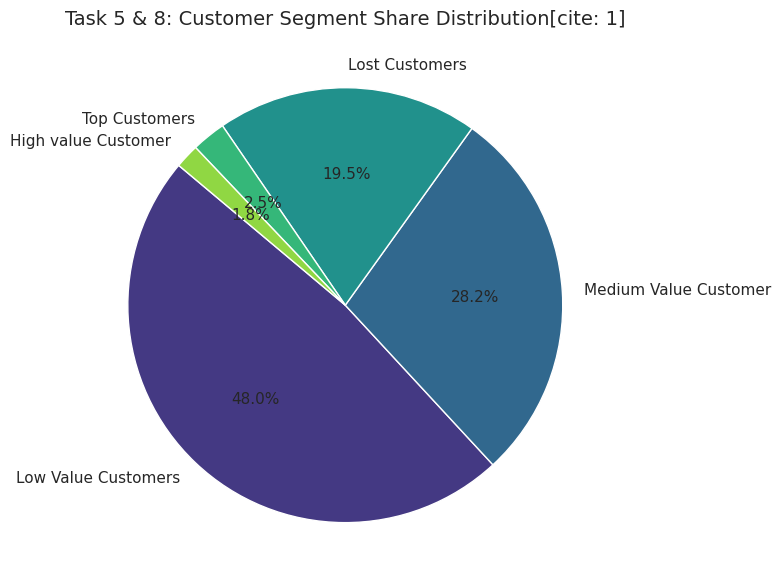

✅ Task 5 & 8 Complete Visualized.
--------------------------------------------------------------------------------


In [10]:
# =====================================================================
# TASK 5 & 8: CUSTOMER DISTRIBUTION VISUALIZATION[cite: 1]
# =====================================================================
print("Executing Task 5 & 8: Rendering global volume share pie chart...")

plt.figure(figsize=(8, 6))
segment_counts = rfm_df['Customer_segment'].value_counts()
plt.pie(segment_counts, labels=segment_counts.index, autopct='%1.1f%%', startangle=140,
        colors=sns.color_palette("viridis", len(segment_counts)))
plt.title('Task 5 & 8: Customer Segment Share Distribution[cite: 1]')
plt.tight_layout()
plt.show()

print("✅ Task 5 & 8 Complete Visualized.")
print("-" * 80)

Executing Task 6: Calculating and graphing macro revenue contributions...


/tmp/ipykernel_651/2251053747.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=revenue_dist.values, y=revenue_dist.index, palette="plasma")


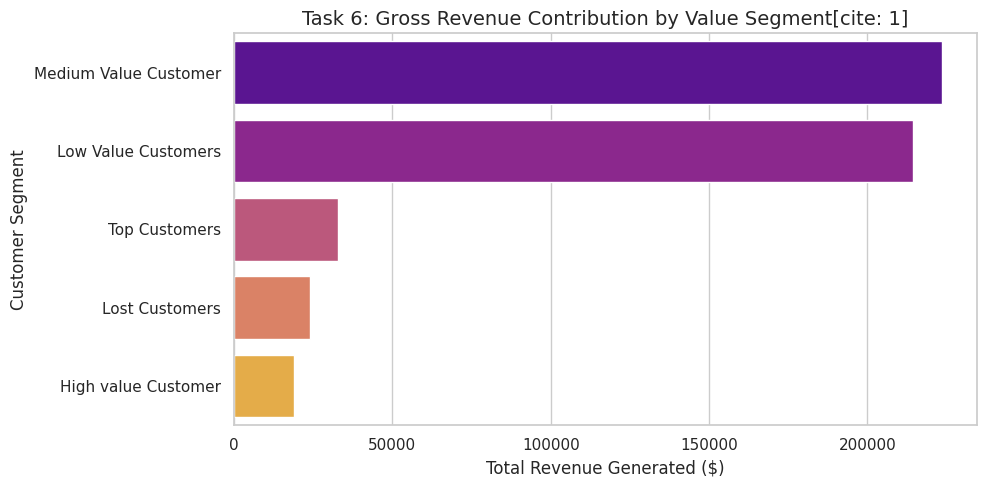

✅ Task 6 Complete Visualized.
--------------------------------------------------------------------------------


In [11]:
# =====================================================================
# TASK 6: REVENUE CONTRIBUTION BY SEGMENT[cite: 1]
# =====================================================================
print("Executing Task 6: Calculating and graphing macro revenue contributions...")

plt.figure(figsize=(10, 5))
revenue_dist = rfm_df.groupby('Customer_segment')['Monetary'].sum().sort_values(ascending=False)
sns.barplot(x=revenue_dist.values, y=revenue_dist.index, palette="plasma")

plt.title('Task 6: Gross Revenue Contribution by Value Segment[cite: 1]')
plt.xlabel('Total Revenue Generated ($)')
plt.ylabel('Customer Segment')
plt.tight_layout()
plt.show()

print("✅ Task 6 Complete Visualized.")
print("-" * 80)

Executing Task 7: Plotting underlying distributions for standalone RFM variables...


/tmp/ipykernel_651/3986061300.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Frequency', data=rfm_df, ax=axes[1], palette='crest')


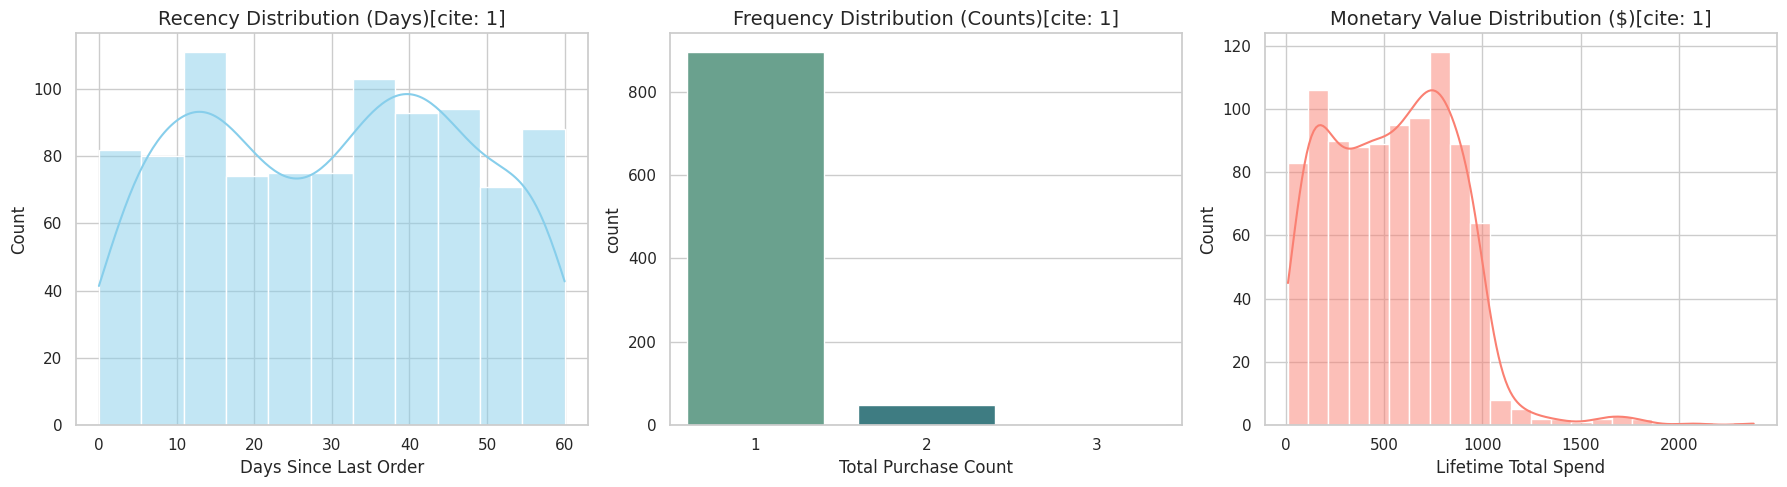

✅ Task 7 Complete Visualized.
--------------------------------------------------------------------------------


In [12]:
# =====================================================================
# TASK 7: INDIVIDUAL METRIC DISTRIBUTIONS (RECENCY, FREQUENCY, MONETARY)[cite: 1]
# =====================================================================
print("Executing Task 7: Plotting underlying distributions for standalone RFM variables...")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Recency Distribution Subplot[cite: 1]
sns.histplot(rfm_df['Recency'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Recency Distribution (Days)[cite: 1]')
axes[0].set_xlabel('Days Since Last Order')

# Frequency Distribution Subplot[cite: 1]
sns.countplot(x='Frequency', data=rfm_df, ax=axes[1], palette='crest')
axes[1].set_title('Frequency Distribution (Counts)[cite: 1]')
axes[1].set_xlabel('Total Purchase Count')

# Monetary Distribution Subplot[cite: 1]
sns.histplot(rfm_df['Monetary'], kde=True, ax=axes[2], color='salmon')
axes[2].set_title('Monetary Value Distribution ($)[cite: 1]')
axes[2].set_xlabel('Lifetime Total Spend')

plt.tight_layout()
plt.show()

print("✅ Task 7 Complete Visualized.")
print("-" * 80)

Executing Task 9: Cross-referencing geographic footprint with value segments...


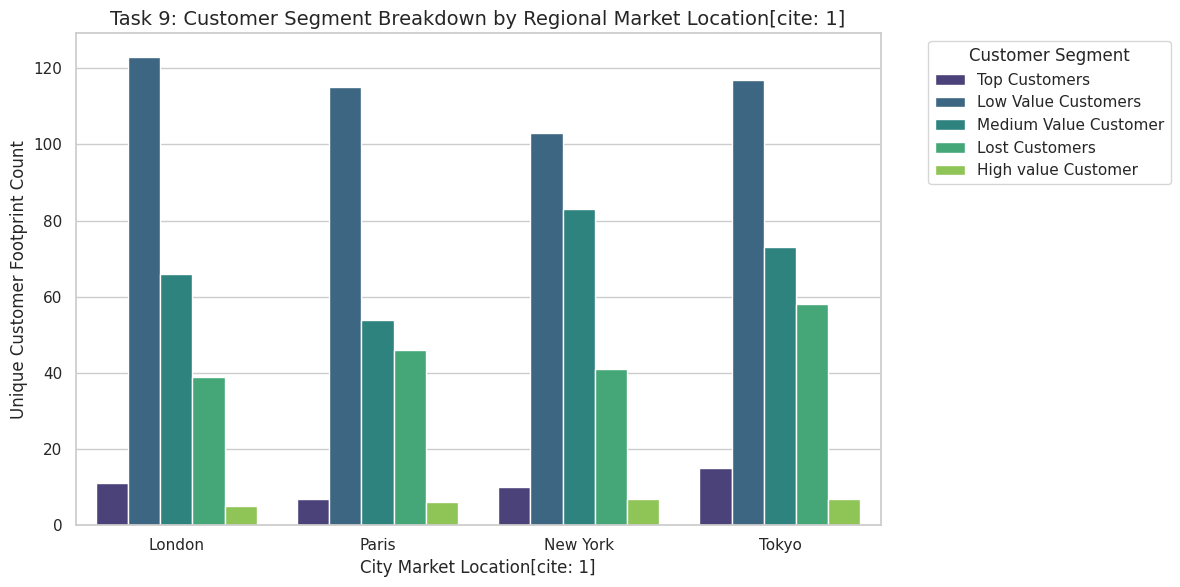

✅ Task 9 Complete Visualized.
--------------------------------------------------------------------------------


In [13]:
# =====================================================================
# TASK 9: GEOGRAPHIC LOCATION DISTRIBUTION ANALYSIS[cite: 1]
# =====================================================================
print("Executing Task 9: Cross-referencing geographic footprint with value segments...")

# Unify geo-spatial tags back to the deduplicated customer metrics
geo_df = df[['CustomerID', 'Location']].drop_duplicates()
rfm_geo = rfm_df.merge(geo_df, on='CustomerID')

plt.figure(figsize=(12, 6))
sns.countplot(data=rfm_geo, x='Location', hue='Customer_segment', palette='viridis')

plt.title('Task 9: Customer Segment Breakdown by Regional Market Location[cite: 1]')
plt.xlabel('City Market Location[cite: 1]')
plt.ylabel('Unique Customer Footprint Count')
plt.legend(title='Customer Segment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("✅ Task 9 Complete Visualized.")
print("-" * 80)

Executing Task 10: Evaluating operational transaction days for weekly cyclicality...


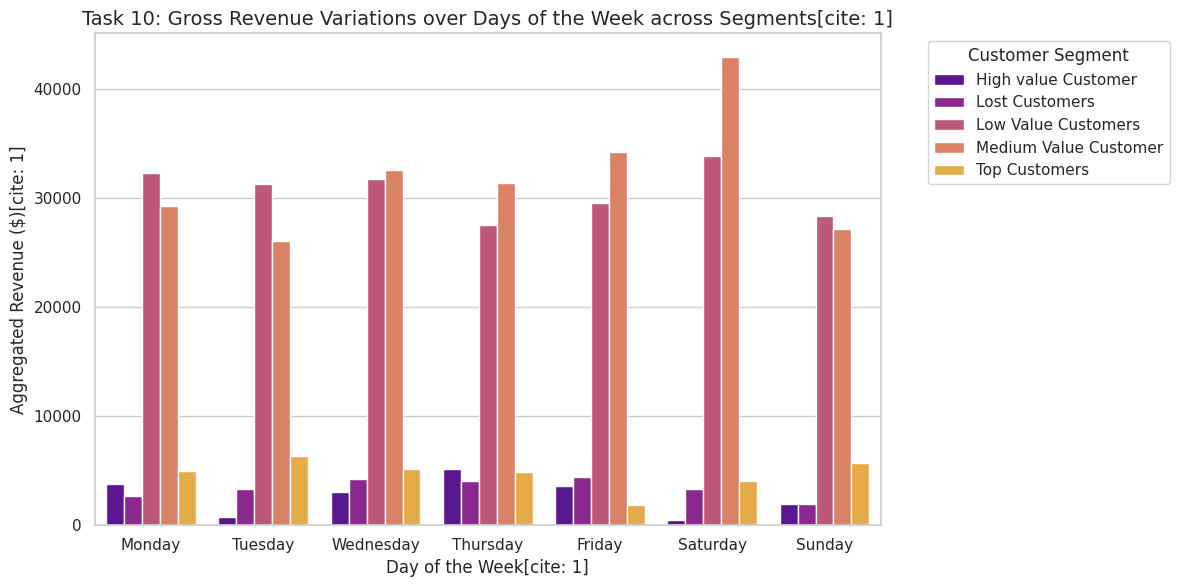

✅ Task 10 Complete Visualized. Full analytical execution finished flawlessly.


In [14]:
# =====================================================================
# TASK 10: DAY OF THE WEEK VARIATION ANALYSIS[cite: 1]
# =====================================================================
print("Executing Task 10: Evaluating operational transaction days for weekly cyclicality...")

# Process explicit calendar days
df['DayOfWeek'] = df['PurchaseDate'].dt.day_name()
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Synthesize segment data into temporal metrics
rfm_days = df.merge(rfm_df[['CustomerID', 'Customer_segment']], on='CustomerID')
day_revenue = rfm_days.groupby(['Customer_segment', 'DayOfWeek'])['TransactionAmount'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(
    data=day_revenue,
    x='DayOfWeek',
    y='TransactionAmount',
    hue='Customer_segment',
    order=days_order,
    palette='plasma'
)

plt.title('Task 10: Gross Revenue Variations over Days of the Week across Segments[cite: 1]')
plt.xlabel('Day of the Week[cite: 1]')
plt.ylabel('Aggregated Revenue ($)[cite: 1]')
plt.legend(title='Customer Segment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("✅ Task 10 Complete Visualized. Full analytical execution finished flawlessly.")
print("=" * 80)